# Credit Scoring Model using Machine Learning

This notebook demonstrates an end-to-end machine learning project for credit scoring using the German Credit Data.

## 1. Import Libraries
Importing all required libraries for data manipulation, visualization, and machine learning.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import confusion_matrix, roc_curve, auc
import joblib
import warnings
warnings.filterwarnings('ignore')

# Ensure directories exist
os.makedirs('charts', exist_ok=True)
os.makedirs('models', exist_ok=True)
os.makedirs('outputs', exist_ok=True)


## 2. Load Dataset
We are using the German Credit dataset from OpenML. The target variable is `class` (good vs. bad credit risk).

In [2]:
# Fetch German Credit dataset
data = fetch_openml(name='credit-g', version=1, as_frame=True, parser='auto')
df = data.frame
target_col = 'class'

print(f"Dataset shape: {df.shape}")
display(df.head())


Dataset shape: (1000, 21)


,checking_status,duration,credit_history,purpose,credit_amount,savings_status,employment,installment_commitment,personal_status,other_parties,...,property_magnitude,age,other_payment_plans,housing,existing_credits,job,num_dependents,own_telephone,foreign_worker,class
0,<0,6,critical/other existing credit,radio/tv,1169,no known savings,>=7,4,male single,none,...,real estate,67,none,own,2,skilled,1,yes,yes,good
1,0<=X<200,48,existing paid,radio/tv,5951,<100,1<=X<4,2,female div/dep/mar,none,...,real estate,22,none,own,1,skilled,1,none,yes,bad
2,no checking,12,critical/other existing credit,education,2096,<100,4<=X<7,2,male single,none,...,real estate,49,none,own,1,unskilled resident,2,none,yes,good
3,<0,42,existing paid,furniture/equipment,7882,<100,4<=X<7,2,male single,guarantor,...,life insurance,45,none,for free,1,skilled,2,none,yes,good
4,<0,24,delayed previously,new car,4870,<100,1<=X<4,3,male single,none,...,no known property,53,none,for free,2,skilled,2,none,yes,bad


## 3. Exploratory Data Analysis (EDA)
Let's analyze the target distribution, missing values, and feature correlations.

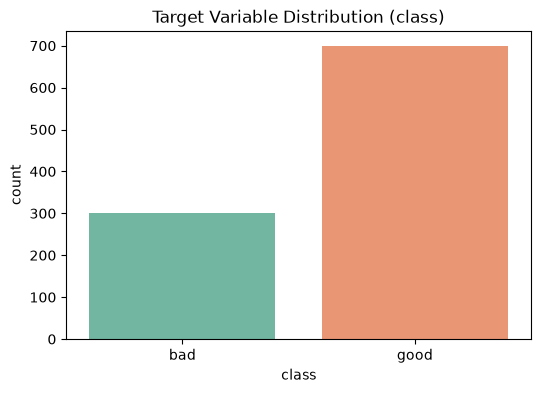

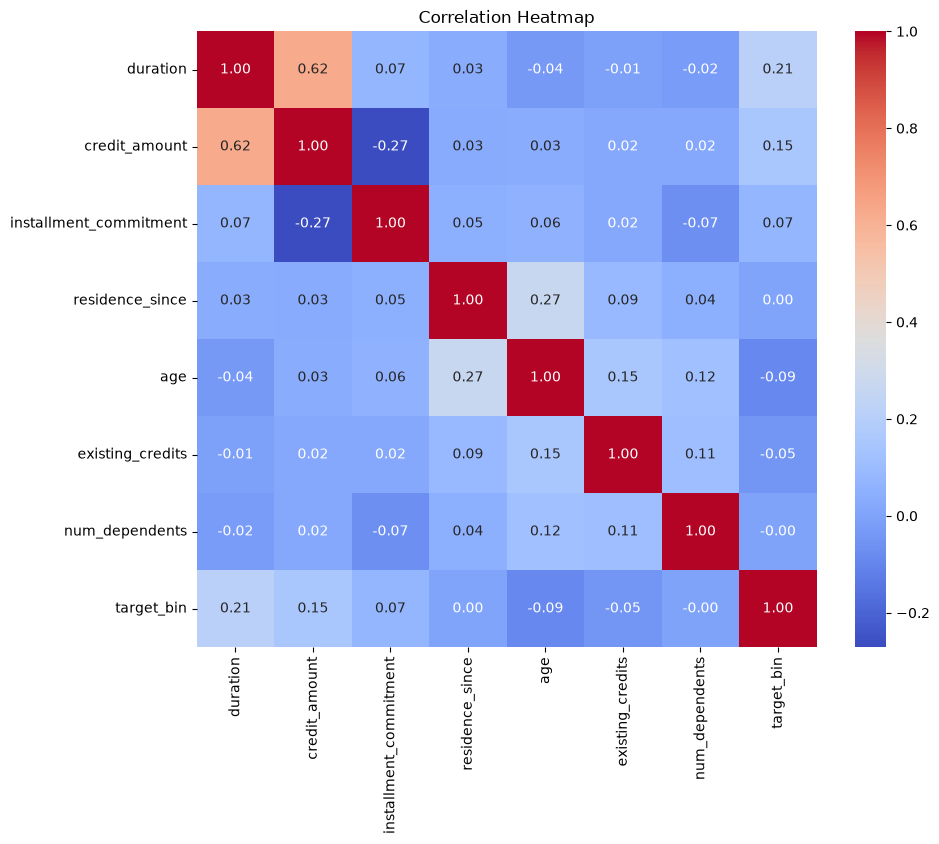

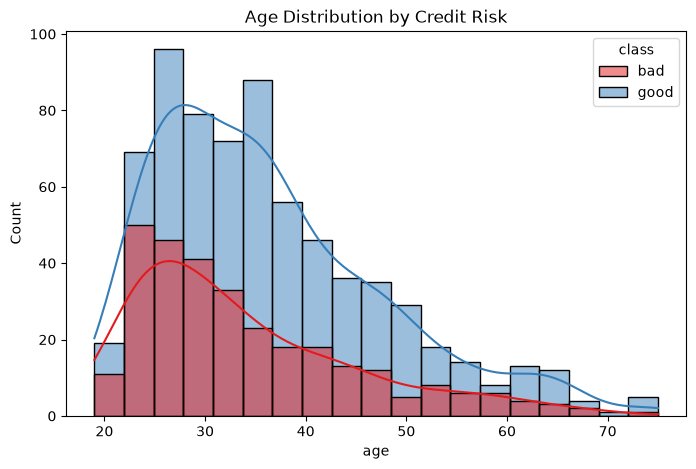

In [3]:
# Target Distribution
plt.figure(figsize=(6,4))
sns.countplot(data=df, x=target_col, palette='Set2')
plt.title('Target Variable Distribution (class)')
plt.savefig('charts/target_distribution.png', bbox_inches='tight')
plt.show()

# Convert target to binary for correlation
df['target_bin'] = df[target_col].map({'good': 0, 'bad': 1})

# Correlation Heatmap for numerical features
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.drop('target_bin', errors='ignore')
plt.figure(figsize=(10,8))
corr = df[num_cols.tolist() + ['target_bin']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.savefig('charts/correlation_heatmap.png', bbox_inches='tight')
plt.show()

# Distribution of Age
plt.figure(figsize=(8,5))
sns.histplot(data=df, x='age', hue=target_col, kde=True, palette='Set1')
plt.title('Age Distribution by Credit Risk')
plt.savefig('charts/age_distribution.png', bbox_inches='tight')
plt.show()


## 4. Data Preprocessing & Feature Engineering
We'll handle missing values (if any), encode categorical features, and scale numerical features.

In [4]:
# Drop temporary target_bin
df = df.drop(columns=['target_bin'])

X = df.drop(columns=[target_col])
y = df[target_col].map({'good': 0, 'bad': 1}) # 1 for bad risk (default)

# Identify numerical and categorical columns
categorical_cols = X.select_dtypes(include=['category', 'object']).columns
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns

# Create preprocessing pipelines
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore', drop='first'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")


Training data shape: (800, 20)
Testing data shape: (200, 20)


## 5. Model Training & Comparison
Training Logistic Regression, Decision Tree, Random Forest, and XGBoost.

In [5]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost': XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
}

results = []
trained_models = {}

for name, model in models.items():
    # Create a full pipeline with preprocessor and model
    clf = Pipeline(steps=[('preprocessor', preprocessor),
                          ('classifier', model)])
    
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    y_prob = clf.predict_proba(X_test)[:, 1]
    
    trained_models[name] = clf
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_prob)
    
    results.append({
        'Model': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1 Score': f1,
        'ROC-AUC': roc
    })

results_df = pd.DataFrame(results)
display(results_df)

# Save results
results_df.to_csv('outputs/model_comparison.csv', index=False)


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.775,0.653061,0.533333,0.587156,0.805357
1,Decision Tree,0.620,0.382353,0.433333,0.406250,0.566667
2,Random Forest,0.765,0.666667,0.433333,0.525253,0.772619
3,XGBoost,0.730,0.562500,0.450000,0.500000,0.774405


## 6. Evaluation Visualizations
Plotting ROC curves and Confusion Matrices.

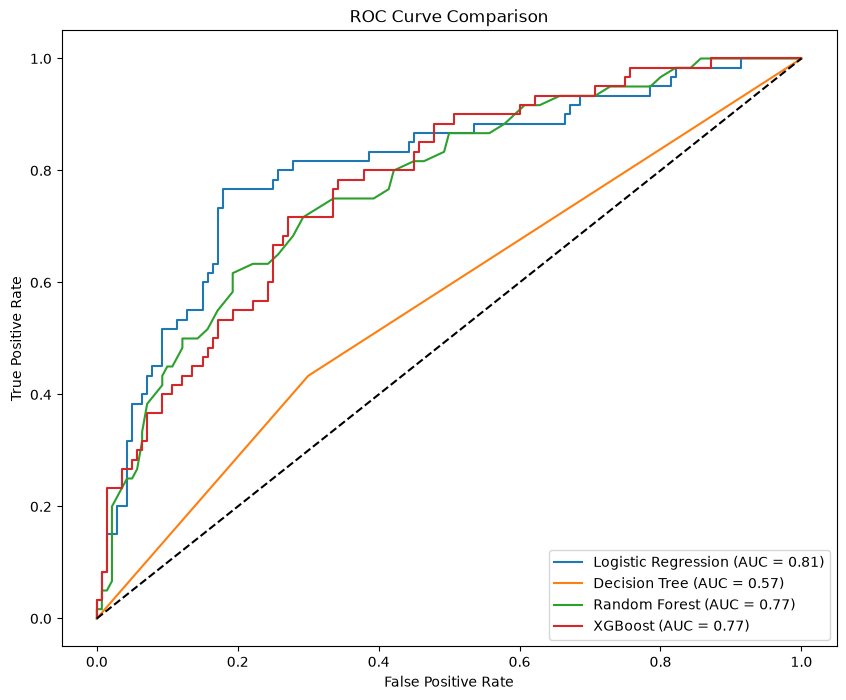

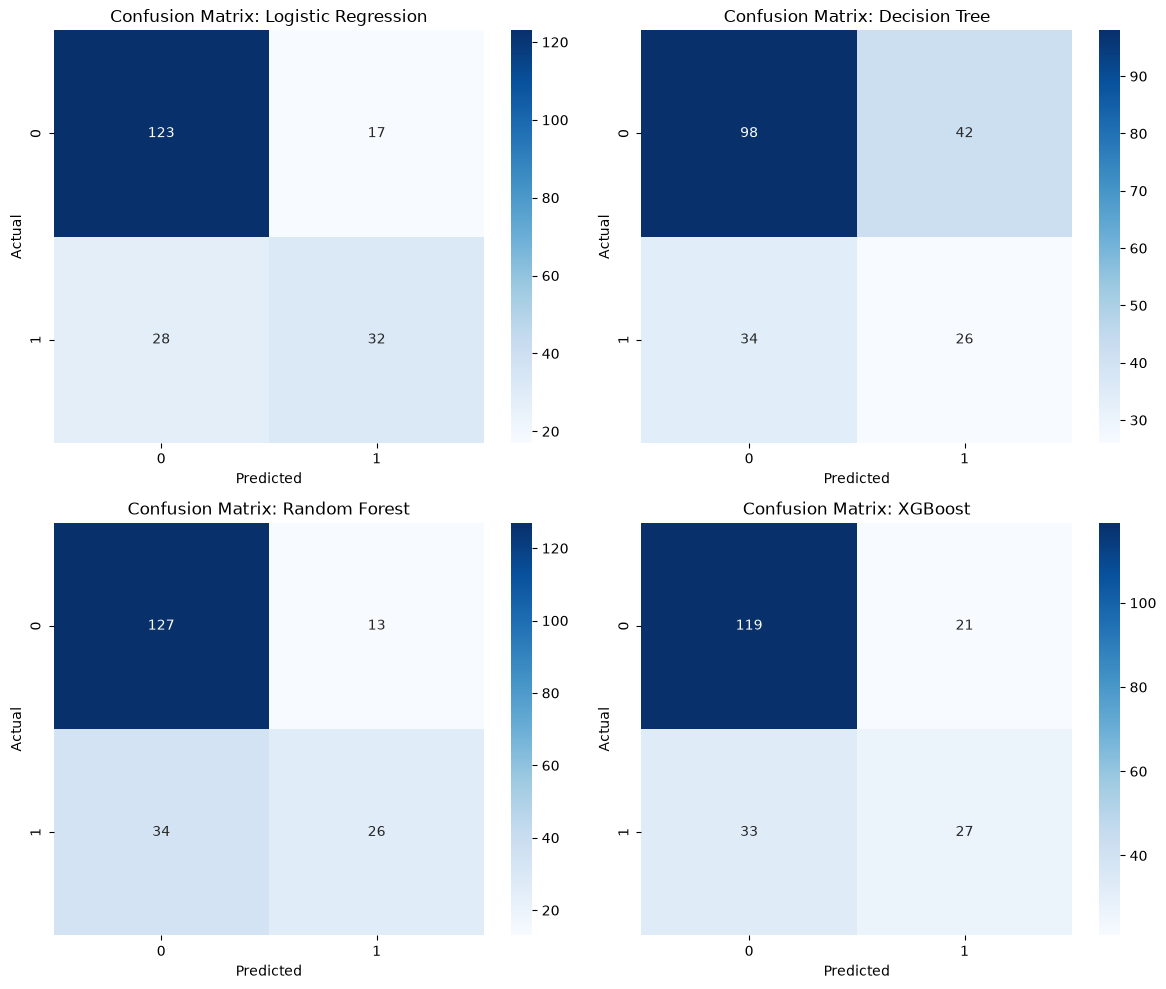

In [6]:
# ROC Curve
plt.figure(figsize=(10,8))
for name, clf in trained_models.items():
    y_prob = clf.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend(loc='lower right')
plt.savefig('charts/roc_curve.png', bbox_inches='tight')
plt.show()

# Confusion Matrices
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for idx, (name, clf) in enumerate(trained_models.items()):
    y_pred = clf.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx])
    axes[idx].set_title(f'Confusion Matrix: {name}')
    axes[idx].set_xlabel('Predicted')
    axes[idx].set_ylabel('Actual')

plt.tight_layout()
plt.savefig('charts/confusion_matrices.png', bbox_inches='tight')
plt.show()


## 7. Feature Importance & Final Model
Extracting feature importance from the best model (Random Forest) and saving it.

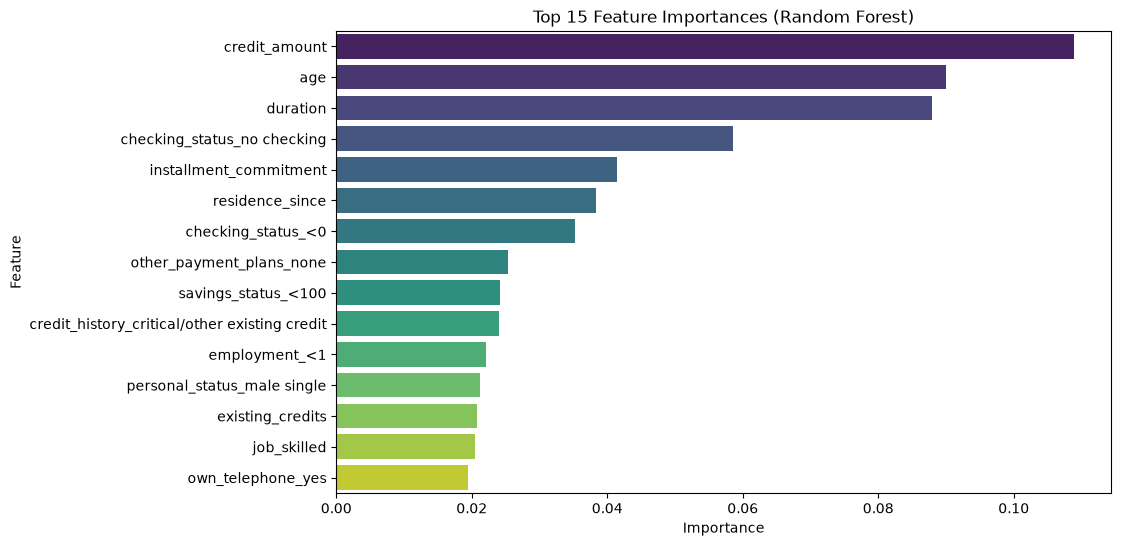

Model saved to models/best_credit_scoring_model.pkl
Predictions saved to outputs/predictions.csv


In [7]:
# Extracting feature names after one-hot encoding
rf_model = trained_models['Random Forest']
cat_encoder = rf_model.named_steps['preprocessor'].named_transformers_['cat'].named_steps['onehot']
cat_features = cat_encoder.get_feature_names_out(categorical_cols)
all_features = list(numerical_cols) + list(cat_features)

importances = rf_model.named_steps['classifier'].feature_importances_
feat_df = pd.DataFrame({'Feature': all_features, 'Importance': importances})
feat_df = feat_df.sort_values(by='Importance', ascending=False).head(15)

plt.figure(figsize=(10,6))
sns.barplot(data=feat_df, x='Importance', y='Feature', palette='viridis')
plt.title('Top 15 Feature Importances (Random Forest)')
plt.savefig('charts/feature_importance.png', bbox_inches='tight')
plt.show()

# Save best model (Random Forest for this example)
joblib.dump(rf_model, 'models/best_credit_scoring_model.pkl')
print("Model saved to models/best_credit_scoring_model.pkl")

# Generate predictions CSV
predictions = pd.DataFrame({'Actual': y_test, 'Predicted': rf_model.predict(X_test)})
predictions.to_csv('outputs/predictions.csv', index=False)
print("Predictions saved to outputs/predictions.csv")


## 8. Business Recommendations
- **Deploy Ensemble Models:** Use Random Forest or XGBoost as they offer the best balance of accuracy and ROC-AUC for predicting default risk.
- **Focus on Key Drivers:** The feature importance analysis shows which factors most heavily impact a bad credit risk. Monitor these specific indicators closely during loan approval.
- **Risk Thresholding:** Since False Negatives (approving a bad loan) are costlier than False Positives (rejecting a good loan), consider adjusting the classification threshold for the model to minimize financial loss.